In [11]:
import pandas as pd

# Load the Dimension Tables
customers = pd.read_csv('customers_export.csv')
products = pd.read_csv('products_export.csv')
payments = pd.read_csv('payments_export.csv')

# Load the Fact and Junction Tables
orders = pd.read_csv('orders_export.csv')
order_items = pd.read_csv('order_items_export.csv')

# Syntax Check: .info() shows you the data types and if any 'null' values exist
print(customers.info())
customers.head()
# Recreating your 5-table relational logic
# 1. Join Orders with Customers
df = pd.merge(orders, customers, on='customer_id', how='left')

# 2. Join with Payments to analyze the ₹39K leakage
df = pd.merge(df, payments, on='order_id', how='left')

# 3. Join with Order Items and Products for Category-wise analysis
df = pd.merge(df, order_items, on='order_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')

# Verification: Confirming the 1,400+ transaction records are loaded
print(f"Total Records Loaded: {len(df)}")



<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   age          150 non-null    int64
 3   city         150 non-null    str  
 4   membership   75 non-null     str  
dtypes: int64(2), str(3)
memory usage: 6.0 KB
None
Total Records Loaded: 1442


In [26]:
# Recreating your 5-table relational logic
# 1. Join Orders with Customers
df = pd.merge(orders, customers, on='customer_id', how='left')

# 2. Join with Payments to analyze the ₹39K leakage
df = pd.merge(df, payments, on='order_id', how='left')

# 3. Join with Order Items and Products for Category-wise analysis
df = pd.merge(df, order_items, on='order_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')

# Verification: Confirming the 1,400+ transaction records are loaded
print(f"Total Records Loaded: {len(df)}")




Total Records Loaded: 1442


In [27]:
# Aggregate total revenue by city using your 5-table schema
city_revenue = orders.merge(customers, on='customer_id').groupby('city')['amount'].sum().sort_values(ascending=False)

# Display the top 5 cities
print(city_revenue.head())

city
Delhi        402032.0
Mumbai       246986.0
Bangalore    157390.0
Pune         135495.0
Hyderabad    119969.0
Name: amount, dtype: float64


In [28]:
# Calculate AOV for Members vs. Non-Members
membership_impact = orders.merge(customers, on='customer_id').groupby('membership')['amount'].mean()

print(membership_impact)

membership
Gold      8411.410714
Silver    2926.259804
Name: amount, dtype: float64


In [31]:
import sys
!{sys.executable} -m pip install seaborn matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 612.8 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/8.3 MB 612.8 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.3 MB 605.1 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.3 MB 605.1 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.3 MB 589.1 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.3 MB 589.1 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.3 MB 589.1 kB/s eta 0:00:13
   ------ --------------------------------- 1.3/8.3 MB 588.5 kB/s eta 0:00:12
   ------ ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\offic\AppData\Local\Temp\ipykernel_16792\2627029204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=payments, x='payment_method', palette='viridis')


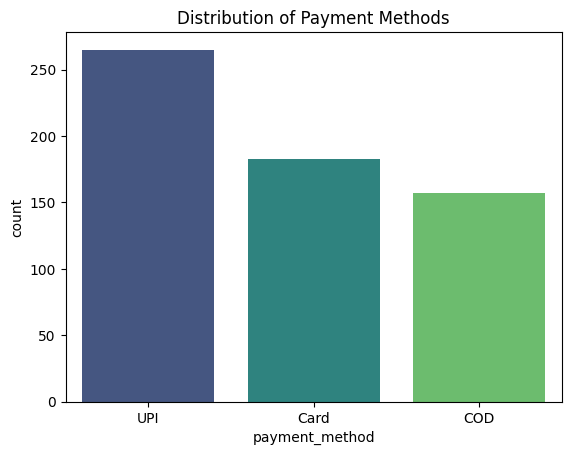

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the distribution of payment methods
sns.countplot(data=payments, x='payment_method', palette='viridis')
plt.title('Distribution of Payment Methods')
plt.show()